<a href="https://colab.research.google.com/github/DuarteVn/Celsius_to_Fahrenheit/blob/main/Convers%C3%A3o_Celsius_para_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Definição do problema:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Etapa 1: Importando biblioteca

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
tf.__version__

'2.18.0'

## Etapa 2: Importação da base de dados

In [3]:
temperature_df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Excel/Celsius-to-Fahrenheit.csv')
temperature_df.reset_index(drop = True, inplace = True)
temperature_df.head(100)

,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0
5,-9,15.8
6,-8,17.6
7,-7,19.4
8,-6,21.2
9,-5,23.0


In [4]:
temperature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Celsius     30 non-null     int64  
 1   Fahrenheit  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


## Etapa 3: Visualização da base de dados

<Axes: xlabel='Celsius', ylabel='Fahrenheit'>

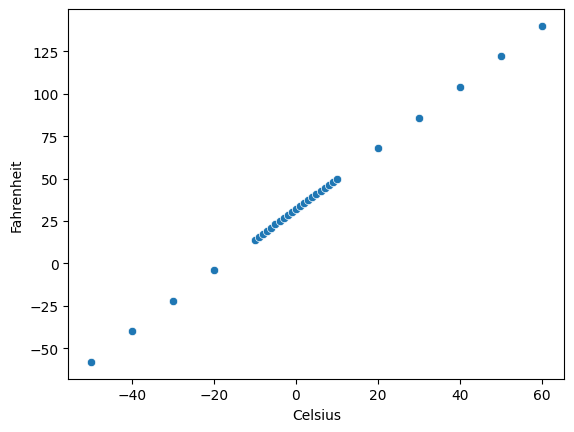

In [5]:
#Gráfico de Dispersão
sns.scatterplot(x='Celsius', y='Fahrenheit', data=temperature_df) # ponto e virgula no final evita o texto

## Etapa 4: Configuração da base de daods de treinamento

In [6]:
x_train = temperature_df['Celsius']
y_train = temperature_df['Fahrenheit']

In [7]:
x_train.shape

(30,)

In [8]:
y_train.shape

(30,)

## Etapa 5: Construção e treinamento do modelo

In [9]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=1, input_shape=[1]))
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss='mean_squared_error')

In [13]:
#Treina o modelo com os dados
epochs_hist = model.fit(x_train, y_train, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - loss: 1.4205
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 5.4721
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.2299
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 1.7781
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3.0991
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.1739
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.7207
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.3084
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.9150
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1.3693
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.0461
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.3679
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0115
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2042
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.5841
Epoch 16/500
1/1 ━

## Avaliação do Modelo

In [14]:
epochs_hist.history.keys()

dict_keys(['loss'])

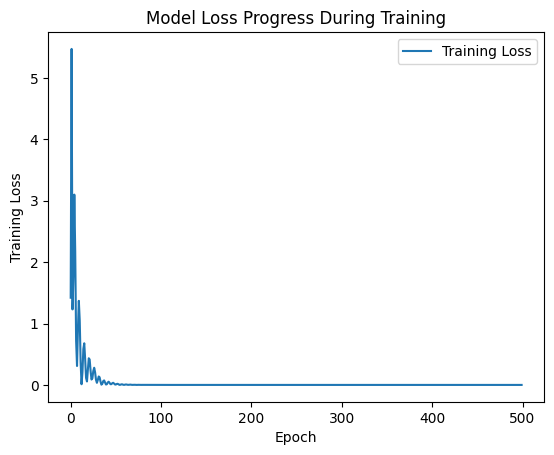

In [15]:
plt.plot(epochs_hist.history['loss'])
plt.title('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['Training Loss'])

In [16]:
model.get_weights()

[array([[1.8]], dtype=float32), array([32.], dtype=float32)]

In [26]:
temp_c = -50
temp_f = model.predict(np.array([temp_c]))
print(f'Temperatura em Celsius: {temp_c}')
print(f'Temperatura em Fahrenheit: {temp_f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Temperatura em Celsius: -50
Temperatura em Fahrenheit: [[-58.]]


In [24]:
temp_f1 = 9/5 * temp_c + 32
print(f'Temperatura em Celsius: {temp_c}')
print(f'Temperatura em Fahrenheit: {temp_f1}')

Temperatura em Celsius: -50
Temperatura em Fahrenheit: -58.0
